<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/CustomerChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading the Dataset**

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
data=pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

## **Understanding the dataset**

In [ ]:
data.head(5)

In [ ]:
data.shape

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.describe()

In [ ]:
data.isnull().sum()

In [ ]:
print(type("TotalChargers"))

In [ ]:
data.duplicated().sum()

In [ ]:
data['Churn'].value_counts()

In [ ]:
data['Churn'].value_counts(normalize=True)

In [ ]:
print(data['gender'].value_counts())
print(data['SeniorCitizen'].value_counts())
print(data['Partner'].value_counts())
print(data['Dependents'].value_counts())
print(data['PhoneService'].value_counts())
print(data['MultipleLines'].value_counts())
print(data['InternetService'].value_counts())
print(data['OnlineSecurity'].value_counts())
print(data['OnlineBackup'].value_counts())
print(data['DeviceProtection'].value_counts())
print(data['TechSupport'].value_counts())
print(data['StreamingTV'].value_counts())
print(data['StreamingMovies'].value_counts())
print(data['Contract'].value_counts())
print(data['PaperlessBilling'].value_counts())
print(data['PaymentMethod'].value_counts())

In [ ]:
# 1. Convert TotalCharges to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# 2. Check missing values after conversion
missing_total_charges = data['TotalCharges'].isnull().sum()
print(f"Missing values in TotalCharges after conversion: {missing_total_charges}")

# 3. Check for duplicate rows (optional)
duplicate_rows = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")


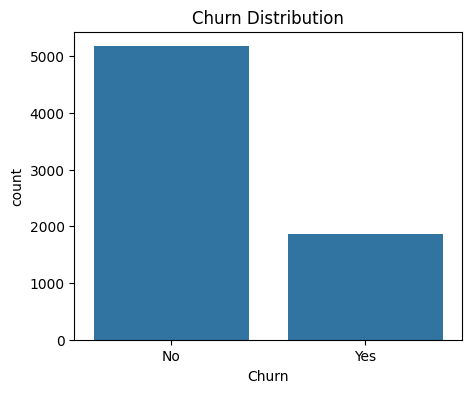

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.show()

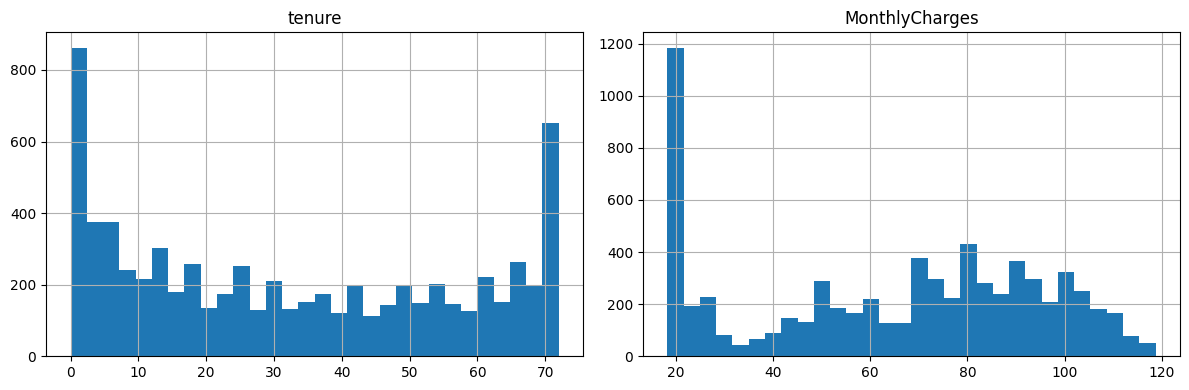

In [ ]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']

# Histograms
data[num_cols].hist(figsize=(12,4), bins=30)
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(12,4))
for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
*****************# ---------------------------
# 1.3.3 Key Categorical Variable Distribution
# ---------------------------
# Optional: Contract or InternetService distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Contract', data=data)
plt.title("Distribution of Contract Type")
plt.show()

# PaymentMethod vs Churn (important insight)
plt.figure(figsize=(6,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=data)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(5,4))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()